# Pretraining on CIFAR10

Instead of TinyImagenet, which still takes awhile, let's do CIFAR10, which is slightly more complicated than MNIST at least. 

## Imports first 

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
import numpy as np

from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
from transformers import ViTForImageClassification, ViTConfig
from transformers import AutoImageProcessor, DefaultDataCollator
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch import nn

## Load data 

In [2]:
dataset = load_dataset("cifar10")

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [4]:
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32),scale=(0.8,1.0),ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])

# Don't need to transform for tests
test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])

def preprocess_train_images(examples):
    examples["pixel_values"] = [train_transform(image.convert("RGB")) for image in examples["img"]]
    return examples
    
def preprocess_test_images(examples):
    examples["pixel_values"] = [test_transform(image.convert("RGB")) for image in examples["img"]]
    return examples


# Apply transformations to the 'train' split
processed_train_dataset = dataset["train"].map(preprocess_train_images, batched=True, remove_columns=["img"])
processed_valid_dataset = dataset["test"].map(preprocess_test_images, batched=True, remove_columns=["img"])

# 3. Create a data collator
data_collator = DefaultDataCollator(return_tensors="pt")

train_dataloader = DataLoader(
    processed_train_dataset,
    shuffle=True,
    batch_size=128, # You can adjust this batch size
    collate_fn=data_collator,
    num_workers=4,
    drop_last=False,
)

valid_dataloader = DataLoader(
    processed_valid_dataset,
    shuffle=True,
    batch_size=128, # You can adjust this batch size
    collate_fn=data_collator,
    num_workers=4,
    drop_last=False,
)


In [5]:
next(iter(train_dataloader))['pixel_values'].shape

torch.Size([128, 3, 32, 32])

## Load a small model in 

In [ ]:
config = ViTConfig.from_pretrained("google/vit-base-patch16-224")
config.num_labels = 10
config.encoder_stride = 4 # Unsure if this is used
config.image_size = 32 # CIFAR10 is smaller 
config.patch_size = 4
config.attention_probs_dropout_prob = 0.0
config.hidden_dropout_prob = 0.0
config.hidden_size = 256
config.intermediate_size = 512
config.num_attention_heads = 8
print(config)

In [7]:
model = ViTForImageClassification(config)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [8]:
model.vit.pooler is None

True

In [9]:
# Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Define the number of total training steps and warmup steps
num_epochs = 30  # Adjust as needed
total_steps = len(train_dataloader) * num_epochs  # Total number of training steps
warmup_steps = int(0.05 * total_steps)  # 5% of total steps for warmup

# Create the learning rate scheduler
scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)


In [10]:
# Training and validation function
def train_and_validate(model, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        correct = 0
        total = 0
        for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
            inputs = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(pixel_values=inputs)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
        
            # Step the scheduler
            scheduler.step()

            _, predicted = torch.max(outputs.logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            train_losses.append( loss.item())

        train_accuracies.append(correct / total)

        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):
                inputs = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(pixel_values=inputs)
                loss = criterion(outputs.logits, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.logits, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total)

        # Print metrics
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}")
        print(f"Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

train_losses, val_losses, train_accuracies, val_accuracies = train_and_validate(
    model, train_dataloader, valid_dataloader, num_epochs
)

Validation Epoch 1: 100%|██████████████████████████████████████████████| 79/79 [00:07<00:00, 11.28it/s]


Epoch 1/30
Train Loss: 1.4610, Train Accuracy: 0.3324
Val Loss: 1.5220, Val Accuracy: 0.4435


Validation Epoch 2: 100%|██████████████████████████████████████████████| 79/79 [00:06<00:00, 12.74it/s]


Epoch 2/30
Train Loss: 1.4252, Train Accuracy: 0.4725
Val Loss: 1.3711, Val Accuracy: 0.5031


Validation Epoch 3: 100%|██████████████████████████████████████████████| 79/79 [00:06<00:00, 11.91it/s]


...

Epoch 28/30
Train Loss: 0.0014, Train Accuracy: 1.0000
Val Loss: 2.1761, Val Accuracy: 0.6750


Validation Epoch 29: 100%|█████████████████████████████████████████████| 79/79 [00:06<00:00, 12.54it/s]


Epoch 29/30
Train Loss: 0.0006, Train Accuracy: 1.0000
Val Loss: 2.1773, Val Accuracy: 0.6746


Validation Epoch 30: 100%|█████████████████████████████████████████████| 79/79 [00:06<00:00, 11.99it/s]

Epoch 30/30
Train Loss: 0.0017, Train Accuracy: 1.0000
Val Loss: 2.1719, Val Accuracy: 0.6746


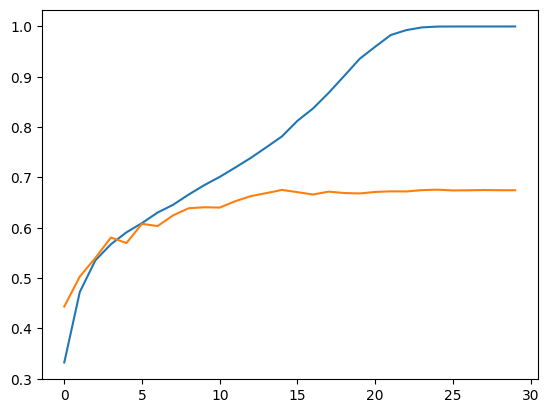

In [11]:
plt.plot(train_accuracies)
plt.plot(val_accuracies)

/tmp/ipykernel_2410114/2282711247.py:2: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1.1)


(np.float64(0.00034509115310387117), 1.1)

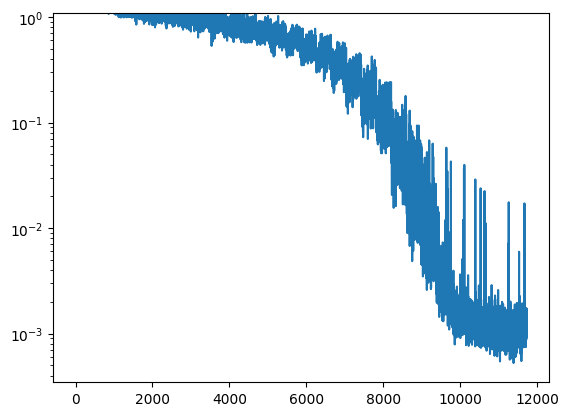

In [12]:
plt.semilogy(train_losses)
plt.ylim(0, 1.1)

In [13]:
from matplotlib import pyplot as plt
import numpy as np

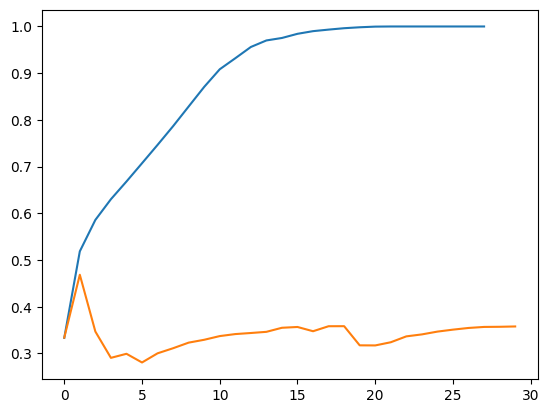

In [14]:
serial_accuracies = np.array([
    0.3334,
    0.5186,
    0.5859,
    0.6302,
    0.6681,
    0.7072,
    0.7465,
    0.7866,
    0.8287,
    0.8707,
    0.9084,
    0.9320,
    0.9561,
    0.9701,
    0.9754,
    0.9843,
    0.9900,
    0.9933,
    0.9963,
    0.9983,
    0.9997,
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000
])

parallel_accuracies = np.array([
    0.3339,
    0.4685,
    0.3469,
    0.2906,
    0.2993,
    0.2807,
    0.3003,
    0.3112,
    0.3232,
    0.3293,
    0.3372,
    0.3415,
    0.3438,
    0.3463,
    0.3550,
    0.3567,
    0.3476,
    0.3583,
    0.3584,
    0.3174,
    0.3172,
    0.3240,
    0.3366,
    0.3408,
    0.3468,
    0.3510,
    0.3546,
    0.3568,
    0.3571,
    0.3578
])
plt.plot(serial_accuracies)
plt.plot(parallel_accuracies)

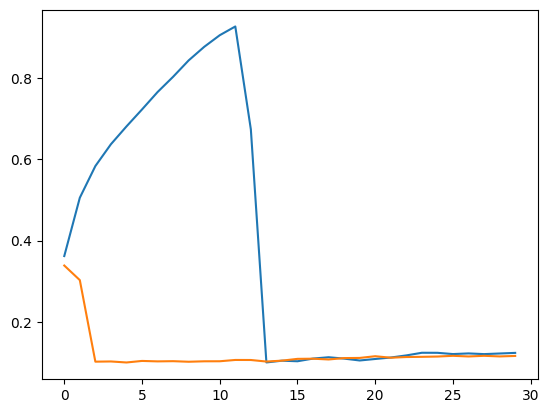

In [15]:
serial_no_norm = np.array([
    0.3620,
    0.5055,
    0.5835,
    0.6372,
    0.6810,
    0.7228,
    0.7656,
    0.8032,
    0.8435,
    0.8769,
    0.9055,
    0.9270,
    0.6738,
    0.1002,
    0.1045,
    0.1031,
    0.1097,
    0.1130,
    0.1096,
    0.1050,
    0.1087,
    0.1123,
    0.1175,
    0.1240,
    0.1239,
    0.1208,
    0.1224,
    0.1207,
    0.1222,
    0.1237
])

parallel_no_norm  = np.array([
    0.3387,
    0.3028,
    0.1021,
    0.1026,
    0.1001,
    0.1039,
    0.1028,
    0.1033,
    0.1019,
    0.1030,
    0.1031,
    0.1063,
    0.1062,
    0.1024,
    0.1046,
    0.1090,
    0.1094,
    0.1075,
    0.1109,
    0.1113,
    0.1155,
    0.1118,
    0.1135,
    0.1140,
    0.1147,
    0.1165,
    0.1149,
    0.1165,
    0.1150,
    0.1162
])

plt.plot(serial_no_norm)
plt.plot(parallel_no_norm)

In [16]:
def extract_losses_from_file(file_name):
    losses = []
    
    with open(file_name, 'r') as file:
        for line in file:
            # Check if the line matches the expected format
            parts = line.split()
            if len(parts) >= 4 and parts[0] == "Train" and parts[1] == "Epoch:":
                try:
                    # Extract the loss value
                    loss = float(parts[4])
                    losses.append(loss)
                except ValueError:
                    # Handle the case where conversion to float fails
                    continue
    
    return np.array(losses)

# Example usage
file_name = 'cifar10-results/vit_2_ti-serial-no-layernorm.out'  # Replace with your actual file name
# file_name = 'cifar10-results/vit_2_ti-serial.out'  # Replace with your actual file name
file_name = 'vit_2_ti-serial.out'
losses_array_serial = extract_losses_from_file(file_name)
file_name = 'cifar10-results/vit_2_ti-parallel-no-layernorm.out'  # Replace with your actual file name
# file_name = 'cifar10-results/vit_2_ti-parallel.out'  # Replace with your actual file name
file_name = 'vit_2_ti-parallel.out'

losses_array_parallel = extract_losses_from_file(file_name)

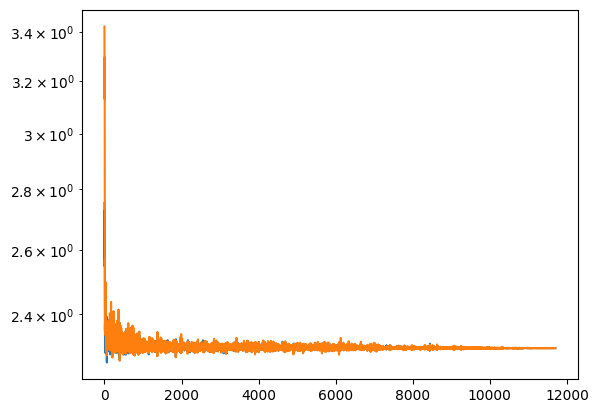

In [17]:
plt.semilogy(losses_array_serial[0:])
plt.semilogy(losses_array_parallel[0:])


## Plot eigenvalues? 

In [19]:
batch = next(iter(train_dataloader))
batch['pixel_values'] = batch['pixel_values'].to('cuda')
print(torch.argmax(model(batch['pixel_values']).logits, dim=1))
print(batch['labels'])

tensor([8, 4, 7, 4, 8, 1, 5, 3, 2, 1, 2, 0, 1, 6, 0, 2, 5, 4, 4, 7, 9, 2, 1, 1,
        4, 2, 2, 4, 8, 9, 5, 9, 1, 2, 0, 4, 6, 2, 2, 4, 0, 7, 3, 8, 1, 6, 0, 8,
        0, 6, 5, 0, 9, 7, 4, 0, 8, 8, 7, 9, 9, 1, 1, 5, 9, 0, 5, 3, 5, 0, 6, 2,
        2, 3, 1, 6, 0, 1, 1, 3, 3, 4, 0, 1, 8, 7, 7, 6, 4, 7, 3, 8, 2, 8, 6, 6,
        4, 3, 3, 4, 1, 6, 1, 7, 7, 1, 4, 1, 8, 6, 4, 2, 4, 8, 8, 6, 5, 0, 7, 7,
        1, 4, 3, 6, 7, 8, 2, 9], device='cuda:0')
tensor([8, 4, 7, 4, 8, 1, 5, 3, 2, 1, 2, 0, 1, 6, 0, 2, 5, 4, 4, 7, 9, 2, 1, 1,
        4, 2, 2, 4, 8, 9, 5, 9, 1, 2, 0, 4, 6, 2, 2, 4, 0, 7, 3, 8, 1, 6, 0, 8,
        0, 6, 5, 0, 9, 7, 4, 0, 8, 8, 7, 9, 9, 1, 1, 5, 9, 0, 5, 3, 5, 0, 6, 2,
        2, 3, 1, 6, 0, 1, 1, 3, 3, 4, 0, 1, 8, 7, 7, 6, 4, 7, 3, 8, 2, 8, 6, 6,
        4, 3, 3, 4, 1, 6, 1, 7, 7, 1, 4, 1, 8, 6, 4, 2, 4, 8, 8, 6, 5, 0, 7, 7,
        1, 4, 3, 6, 7, 8, 2, 9])


In [38]:
input_tensor = torch.randn(1, 65, 256, requires_grad=True).to('cuda')

layer = model.vit.encoder.layer[1]
output = layer(input_tensor)[0]  # Forward pass
    
# Define a function for the layer
def layer_function(sample_input):
    return layer(sample_input)[0]

jacobian = jacobian(layer_function, input_tensor)

In [39]:
jacobian = jacobian.cpu().detach().numpy()
jacobian = jacobian.reshape((65 * 256, 65 * 256))

In [40]:
jacobian.shape

(16640, 16640)

In [41]:
def power_iteration(A, num_iterations=100):
    # Random initial vector
    b_k = np.random.rand(A.shape[1])
    
    for i in range(num_iterations):
        # Multiply by the matrix
        b_k1 = np.dot(A, b_k)
        
        # Normalize the vector
        b_k1_norm = np.linalg.norm(b_k1)
        b_k = b_k1 / b_k1_norm
        print(i, end='\t')
    
    # Rayleigh quotient gives the eigenvalue
    eigenvalue = np.dot(b_k.T, np.dot(A, b_k)) / np.dot(b_k.T, b_k)
    return eigenvalue


In [42]:
largest_eigenvalue = power_iteration(jacobian, num_iterations=100)


0	1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23	24	25	26	27	28	29	30	31	32	33	34	35	36	37	38	39	40	41	42	43	44	45	46	47	48	49	50	51	52	53	54	55	56	57	58	59	60	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	

In [44]:
largest_eigenvalue

np.float64(1.95482513409555)

In [45]:
model_2 = ViTForImageClassification(config)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2 = model_2.to(device)

batch = next(iter(train_dataloader))
batch['pixel_values'] = batch['pixel_values'].to('cuda')
print(torch.argmax(model_2(batch['pixel_values']).logits, dim=1))
print(batch['labels'])

tensor([5, 3, 3, 3, 5, 5, 3, 5, 8, 3, 3, 5, 9, 3, 9, 5, 8, 3, 3, 8, 3, 5, 5, 5,
        5, 5, 9, 3, 4, 5, 8, 5, 9, 3, 8, 8, 3, 9, 3, 5, 5, 3, 3, 5, 3, 5, 3, 3,
        9, 3, 5, 5, 5, 9, 8, 5, 9, 8, 9, 5, 8, 3, 5, 9, 5, 5, 5, 9, 3, 5, 4, 3,
        9, 3, 5, 8, 8, 5, 9, 7, 9, 9, 4, 8, 9, 3, 3, 7, 5, 3, 3, 5, 3, 5, 9, 9,
        0, 9, 5, 5, 3, 5, 3, 3, 5, 3, 7, 5, 3, 9, 3, 3, 5, 5, 8, 9, 9, 5, 5, 5,
        3, 9, 5, 5, 3, 5, 5, 5], device='cuda:0')
tensor([3, 4, 1, 0, 0, 6, 5, 7, 0, 9, 1, 1, 0, 7, 1, 2, 7, 7, 9, 7, 4, 4, 1, 9,
        5, 3, 5, 6, 4, 2, 4, 5, 3, 0, 8, 3, 1, 2, 7, 3, 8, 1, 2, 4, 6, 6, 5, 1,
        1, 3, 4, 3, 3, 8, 0, 3, 4, 5, 8, 8, 3, 6, 6, 0, 5, 3, 3, 3, 6, 3, 4, 4,
        9, 5, 5, 6, 4, 9, 0, 3, 3, 1, 4, 5, 6, 2, 9, 2, 5, 0, 7, 9, 9, 5, 2, 9,
        1, 9, 4, 4, 7, 6, 8, 9, 7, 8, 7, 3, 8, 3, 7, 9, 7, 6, 8, 9, 8, 3, 7, 7,
        3, 4, 4, 3, 7, 6, 9, 6])


In [46]:
input_tensor = torch.randn(1, 65, 256, requires_grad=True).to('cuda')

layer = model_2.vit.encoder.layer[1]
output = layer(input_tensor)[0]  # Forward pass
    
# Define a function for the layer
def layer_function(sample_input):
    return layer(sample_input)[0]

# Compute the Jacobian
from torch.autograd.functional import jacobian
jacobian = jacobian(layer_function, input_tensor)

In [47]:
jacobian = jacobian.cpu().detach().numpy()
jacobian = jacobian.reshape((65 * 256, 65 * 256))

In [48]:
largest_eigenvalue = power_iteration(jacobian, num_iterations=100)


0	1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23	24	25	26	27	28	29	30	31	32	33	34	35	36	37	38	39	40	41	42	43	44	45	46	47	48	49	50	51	52	53	54	55	56	57	58	59	60	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	

In [49]:
largest_eigenvalue

np.float64(1.1129736474306966)